# Modeling

Models used:
- LightGBM
- XGBoost
- RandomForest

Evaluation metric:
- MAE (Mean Absolute Error)

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [4]:
import sys

PROJECT_PATH = "/content/drive/MyDrive/Agribora_Final"

sys.path.insert(0, PROJECT_PATH)

In [6]:
#Installation of mlflow
!pip install mlflow

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.4/49.4 kB 1.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.2/50.2 kB 3.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.5/43.5 kB 3.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.8/10.8 MB 71.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.4/3.4 MB 82.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 45.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 147.8/147.8 kB 12.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 9.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 212.0/212.0 kB 12.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 86.3/86.3 kB 7.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 132.2/132.2 kB 10.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 907.0/907.0 kB 35.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2

In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
import mlflow
import mlflow.sklearn
warnings.filterwarnings("ignore")

import data_loader
import preprocessing
import feature
import model
import validation

In [19]:
import os

os.environ["MLFLOW_ALLOW_FILE_STORE"] = "true"

import mlflow

Setting the tracking and experiment

In [10]:
#Setting the tracking
mlflow.set_tracking_uri("file:/content/drive/MyDrive/Agribora_Final/mlruns")
mlflow.set_experiment("AgriBORA_Maize_Forecasting")

<Experiment: artifact_location='file:///content/drive/MyDrive/Agribora_Final/mlruns/834918197561942796', creation_time=1779781672975, effective_trace_archival_retention=None, experiment_id='834918197561942796', last_update_time=1779781672975, lifecycle_stage='active', name='AgriBORA_Maize_Forecasting', tags={}, trace_location=None, workspace='default'>

In [11]:
import os

os.listdir("/content/drive/MyDrive/Agribora_Final")

['data',
 '.ipynb_checkpoints',
 '__pycache__',
 'production.py',
 'requirements.txt',
 'notebook',
 'forescating.py',
 'validation.py',
 'mlruns',
 'model.py',
 'feature.py',
 'final_model.pkl',
 'eda.py',
 'data_loader.py',
 'preprocessing.py']

In [20]:
data = data_loader.load_all_data()

TARGET_COUNTIES = data_loader.get_target_counties()

print(TARGET_COUNTIES)

Loaded: agriBORA_maize_prices.csv
Shape : (239, 6)
Loaded: agriBORA_maize_prices_weeks_46_to_51.csv
Shape : (30, 6)
Loaded: kamis_maize_prices.csv
Shape : (21888, 15)
Loaded: kamis_maize_prices_raw.csv
Shape : (22525, 16)
Loaded: agriBORA_Final_Weeks_maize_price.csv
Shape : (10, 4)

All datasets loaded successfully
['Kiambu', 'Kirinyaga', 'Mombasa', 'Nairobi', 'Uasin-Gishu']


In [21]:
df = preprocessing.clean_agri_data(
    data['agri_df'],
    data['agriW51_df'],
    TARGET_COUNTIES
)

display(df.head())

CLEANING AGRIBORA DATA
Final shape: (232, 6)


,County,Date,WholeSale,Commodity_Classification,Year_Week,WeekofYear
0,Kiambu,2023-10-02,46.67,Dry_White_Maize,2023-40,40
1,Kiambu,2024-01-15,47.78,Dry_White_Maize,2024-03,3
2,Kiambu,2024-02-05,47.78,Dry_White_Maize,2024-06,6
3,Kiambu,2024-02-12,44.44,Dry_White_Maize,2024-07,7
4,Kiambu,2024-03-04,37.78,Dry_White_Maize,2024-10,10


In [22]:
features = ['diff_lag1']


In [23]:
X_train, y_train, X_val, y_val = model.prepare_train_val(
    final_df,
    features,
    target
)

print(X_train.shape)
print(X_val.shape)

NameError: name 'final_df' is not defined

In [ ]:
results_df, trained_models, best_model, best_model_name = model.train_models(
    X_train,
    y_train,
    X_val,
    y_val
)

MODEL TRAINING

Training LightGBM...


2026/05/28 08:44:38 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000202 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 75
[LightGBM] [Info] Number of data points in the train set: 437, number of used features: 1
[LightGBM] [Info] Start training from score 0.016900
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best

2026/05/28 08:44:39 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


Train MAE: 0.5962
Val MAE: 0.7124
RMSE: 1.4484

Training XGBoost...


2026/05/28 08:44:46 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/28 08:44:47 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


Train MAE: 0.4369
Val MAE: 0.8247
RMSE: 1.5089

Training RandomForest...


2026/05/28 08:44:54 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/28 08:44:54 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


Train MAE: 0.5189
Val MAE: 0.7433
RMSE: 1.4694

BEST MODEL: LightGBM


In [ ]:
display(results_df)

,Model,Train_MAE,Val_MAE,RMSE
0,LightGBM,0.596179,0.712411,1.448437
1,XGBoost,0.436872,0.824748,1.508927
2,RandomForest,0.518921,0.743263,1.469434


**Visualize the models**

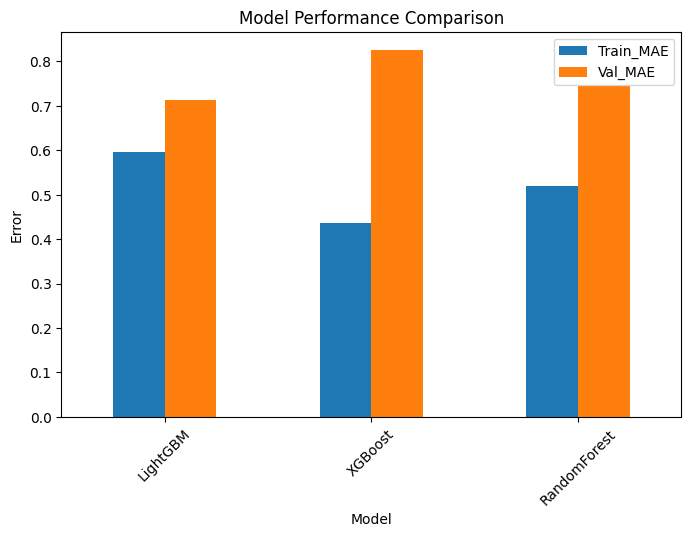

In [ ]:
results_df.set_index("Model")[[
    "Train_MAE",
    "Val_MAE"
]].plot(
    kind='bar',
    figsize=(8,5),


    )

plt.title("Model Performance Comparison")
plt.ylabel("Error")
plt.xticks(rotation=45)


plt.show()

In [ ]:
#check overfitting
model.check_overfitting(
    results_df,
    best_model_name
)


OVERFITTING CHECK
Train MAE: 0.5962
Validation MAE: 0.7124
Gap Ratio: 0.1632
 Mild Overfitting


In [ ]:
best_run = mlflow.search_runs(order_by=["metrics.MAE ASC"]).iloc[0]
print(best_run)

run_id                                      58c3ff840bcc460fa598e1049f9dfdca
experiment_id                                             834918197561942796
status                                                              FINISHED
artifact_uri               file:///content/drive/MyDrive/Agribora_Final/m...
start_time                                  2026-05-28 07:33:58.683000+00:00
end_time                                    2026-05-28 07:34:05.919000+00:00
metrics.rmse                                                        1.469434
metrics.train_mae                                                   0.518921
metrics.val_mae                                                     0.743263
params.model_name                                               RandomForest
tags.mlflow.user                                                        root
tags.mlflow.source.name             fileId=1mYNrekQmEASu3LDTQ7Dd7oLcNehhBcZ9
tags.mlflow.runName                                             RandomForest

## Overfitting Analysis

The gap between training and validation performance was analyzed.

A small gap indicates that the model generalizes well to unseen future data.

## Model Comparison

Three machine learning models were evaluated:

- LightGBM
- XGBoost
- Random Forest

Performance was measured using:
- MAE
- RMSE

The best-performing model was selected for production forecasting.

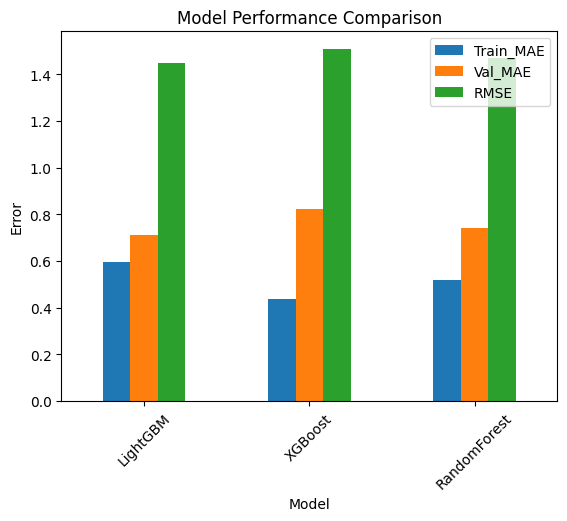

In [ ]:
import matplotlib.pyplot as plt

results_df.set_index("Model")[["Train_MAE", "Val_MAE", "RMSE"]].plot(kind="bar")
plt.title("Model Performance Comparison")
plt.ylabel("Error")
plt.xticks(rotation=45)
plt.show()

In [ ]:
mlflow.sklearn.log_model(best_model, "best_model")

2026/05/28 09:54:10 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/28 09:54:10 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


In [ ]:
import joblib

pipeline = {
    "model": best_model,
    "features": features,
    "model_name": best_model_name
}

joblib.dump(pipeline, "/content/drive/MyDrive/Agribora_Final/final_model.pkl")

['/content/drive/MyDrive/Agribora_Final/final_model.pkl']

In [ ]:
!mlflow ui --port 5000 &

Backend store URI not provided. Using sqlite:///mlflow.db
Registry store URI not provided. Using backend store URI.
2026/05/28 10:29:07 INFO mlflow.store.db.utils: Creating initial MLflow database tables...
2026/05/28 10:29:07 INFO mlflow.store.db.utils: Updating database tables
[MLflow] Security middleware enabled with default settings (localhost-only). To allow connections from other hosts, use --host 0.0.0.0 and configure --allowed-hosts and --cors-allowed-origins.
2026/05/28 10:29:18 INFO:     Uvicorn running on http://127.0.0.1:5000 (Press CTRL+C to quit)
2026/05/28 10:29:18 INFO:     Started parent process [75341]
2026/05/28 10:30:01 INFO:     Started server process [75389]
2026/05/28 10:30:01 INFO:     Waiting for application startup.
2026/05/28 10:30:01 INFO:     Application startup complete.
2026/05/28 10:30:01 INFO:     Started server process [75386]
2026/05/28 10:30:01 INFO:     Waiting for application startup.
2026/05/28 10:30:01 INFO:     Application startup complete.
2026